In [1]:
# Cell 1 — Imports and connection
import os
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import psycopg2
conn = psycopg2.connect(
    host='127.0.0.1', port=5455, dbname='postgres',
    user='postgres', password='postgres'
)
cur = conn.cursor()
print("Connected.")

Connected.


In [2]:
# Cell 2 — Schema introspection
cur.execute("""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'int'
    AND table_name = 'int_game_team_features'
    ORDER BY ordinal_position
""")
for row in cur.fetchall():
    print(row)

('game_id', 'bigint')
('season', 'integer')
('week', 'integer')
('game_date', 'date')
('team_name', 'text')
('opponent', 'text')
('points_scored', 'integer')
('points_allowed', 'integer')
('win', 'integer')
('off_epa_per_play', 'numeric')
('def_epa_per_play_allowed', 'numeric')
('close_game_epa_per_play', 'numeric')
('close_game_play_count', 'bigint')
('close_game_def_epa_per_play', 'numeric')
('close_game_def_play_count', 'bigint')
('game_script', 'text')
('game_script_avg_margin', 'numeric')
('last3_off_epa_avg', 'numeric')
('last3_win_pct', 'numeric')
('last3_points_scored_avg', 'numeric')
('last3_def_epa_avg', 'numeric')
('last3_points_allowed_avg', 'numeric')
('days_since_last_game', 'integer')
('opp_sp_rating_at_game_time', 'numeric')
('pregame_elo', 'numeric')
('opponent_pregame_elo', 'numeric')
('postgame_elo', 'numeric')
('excitement_index', 'numeric')


In [3]:
# Cell 3 — Load candidate features
candidates = pd.read_csv(os.path.expanduser("~/cfb-analytics/artifacts/candidate_features.csv"))
candidates.columns = candidates.columns.str.strip().str.lower()
keep_cols = set(candidates.loc[candidates["keep"] == True, "column_name"].tolist())

momentum_features = [
    "last3_off_epa_avg",
    "last3_def_epa_avg",
    "last3_win_pct",
    "last3_points_scored_avg",
    "last3_points_allowed_avg",
    "days_since_last_game",
]
print("Candidate feature validation:")
for f in momentum_features:
    status = "✓ keep" if f in keep_cols else "✗ NOT in keep list"
    print(f"  {f:40s} {status}")

Candidate feature validation:
  last3_off_epa_avg                        ✓ keep
  last3_def_epa_avg                        ✓ keep
  last3_win_pct                            ✓ keep
  last3_points_scored_avg                  ✓ keep
  last3_points_allowed_avg                 ✓ keep
  days_since_last_game                     ✓ keep


In [4]:
# Cell 4 — Load game-level data
cur.execute("""
    SELECT
        g.game_id,
        g.season,
        g.week,
        g.team_name,
        g.opponent,
        g.points_scored,
        g.points_allowed,
        g.close_game_epa_per_play,
        g.close_game_def_epa_per_play,
        g.opp_sp_rating_at_game_time,
        g.last3_off_epa_avg,
        g.last3_def_epa_avg,
        g.last3_win_pct,
        g.last3_points_scored_avg,
        g.last3_points_allowed_avg,
        g.days_since_last_game,
        c.conference,
        c2.conference AS opp_conference,
        s.sp_rating   AS team_sp_rating
    FROM int.int_game_team_features g
    JOIN int.int_team_season_context c
        ON g.team_name = c.team_name AND g.season = c.season
    JOIN int.int_team_season_context c2
        ON g.opponent = c2.team_name AND g.season = c2.season
    JOIN int.int_team_season_features s
        ON g.team_name = s.team_name AND g.season = s.season
    WHERE g.points_scored IS NOT NULL
      AND g.points_allowed IS NOT NULL
      AND g.season IN (2022, 2023, 2024)
      AND c.conference IN (
          'SEC','Big Ten','Big 12','ACC','Pac-12',
          'Mountain West','American Athletic','Sun Belt',
          'Mid-American','Conference USA','FBS Independents'
      )
""")
rows = cur.fetchall()
cols = [d[0] for d in cur.description]
gdf = pd.DataFrame(rows, columns=cols)

numeric_cols = [
    "points_scored","points_allowed","close_game_epa_per_play",
    "close_game_def_epa_per_play","opp_sp_rating_at_game_time","team_sp_rating",
    "last3_off_epa_avg","last3_def_epa_avg","last3_win_pct",
    "last3_points_scored_avg","last3_points_allowed_avg","days_since_last_game"
]
gdf[numeric_cols] = gdf[numeric_cols].astype(float)
gdf["point_differential"] = gdf["points_scored"] - gdf["points_allowed"]
gdf["total_points"]       = gdf["points_scored"] + gdf["points_allowed"]

P4_CONFERENCES = {"ACC", "Big 12", "Big Ten", "SEC"}

def assign_tier(row):
    if row["team_name"] == "Notre Dame":
        return "P4"
    if row["team_name"] == "UConn":
        return "G5"
    if row["conference"] in P4_CONFERENCES:
        return "P4"
    return "G5"

gdf["tier"] = gdf.apply(assign_tier, axis=1)

# True conference games only
gdf_conf = gdf[
    (gdf["conference"] == gdf["opp_conference"]) &
    (gdf["conference"] != "FBS Independents")
].copy()
nd_conf = gdf[
    (gdf["team_name"] == "Notre Dame") &
    (gdf["opp_conference"] == "ACC")
].copy()
nd_conf["conference"] = "ACC"
gdf_conf = pd.concat([gdf_conf, nd_conf], ignore_index=True)
gdf_conf = gdf_conf.drop_duplicates(subset=["game_id","team_name"])
gdf_conf = gdf_conf.sort_values(["team_name","season","week"])
gdf_conf["conf_game_num"] = gdf_conf.groupby(
    ["team_name","season"]
).cumcount() + 1

# Conference games 2+ — rolling features non-null
conf_g2plus = gdf_conf[gdf_conf["conf_game_num"] >= 2].copy()

print(f"Total game rows        : {len(gdf):,}")
print(f"Conference game rows   : {len(gdf_conf):,}")
print(f"Conf games 2+ rows     : {len(conf_g2plus):,}")
print(f"Seasons                : {sorted(gdf['season'].unique())}")
print(f"Conferences            : {sorted(gdf_conf['conference'].unique())}")

print(f"\nNull counts per momentum feature (conf_g2plus):")
for col in momentum_features:
    n = conf_g2plus[col].isna().sum()
    pct = n / len(conf_g2plus) * 100
    print(f"  {col:40s} {n:,} ({pct:.1f}%)")

print(f"\nConference game number distribution:")
print(gdf_conf["conf_game_num"].value_counts().sort_index().head(12).to_string())

Total game rows        : 4,472
Conference game rows   : 3,233
Conf games 2+ rows     : 2,846
Seasons                : [np.int64(2022), np.int64(2023), np.int64(2024)]
Conferences            : ['ACC', 'American Athletic', 'Big 12', 'Big Ten', 'Conference USA', 'Mid-American', 'Mountain West', 'Pac-12', 'SEC', 'Sun Belt']

Null counts per momentum feature (conf_g2plus):
  last3_off_epa_avg                        0 (0.0%)
  last3_def_epa_avg                        0 (0.0%)
  last3_win_pct                            0 (0.0%)
  last3_points_scored_avg                  0 (0.0%)
  last3_points_allowed_avg                 0 (0.0%)
  days_since_last_game                     0 (0.0%)

Conference game number distribution:
conf_game_num
1     387
2     385
3     385
4     385
5     384
6     383
7     382
8     370
9     151
10     21


In [5]:
# Cell 5 — Helpers
EPA_ANCHOR = ["close_game_epa_per_play", "close_game_def_epa_per_play"]
CONTROLS   = EPA_ANCHOR + ["opp_sp_rating_at_game_time"]
THRESHOLD  = 0.10

def partial_corr(df_, x_col, y_col, control_cols):
    sub = df_[[x_col, y_col] + control_cols].dropna()
    n = len(sub)
    if n < 30:
        return np.nan, np.nan, n
    def resid(target, predictors):
        X = sub[predictors].values
        y = sub[target].values
        return y - LinearRegression().fit(X, y).predict(X)
    r, p = stats.pearsonr(resid(x_col, control_cols), resid(y_col, control_cols))
    return r, p, n

def ols_stats(x_cols, y_col, df_, label=""):
    sub = df_[[y_col] + x_cols].dropna()
    X = sub[x_cols].values
    y = sub[y_col].values
    reg = LinearRegression().fit(X, y)
    yhat = reg.predict(X)
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res/ss_tot
    n, k = len(y), len(x_cols)
    adj_r2 = 1 - (1-r2)*(n-1)/(n-k-1)
    resid_sd = np.std(y-yhat, ddof=k+1)
    print(f"  {label:55s} R²={r2:.4f}  adj R²={adj_r2:.4f}  resid_SD={resid_sd:.4f}  n={n:,}")
    return r2, adj_r2, resid_sd

def conf_stratified_partial_r(df_, feat, target, controls, label=""):
    """
    Run partial r for a feature against a target across:
    - Full population
    - P4 tier
    - G5 tier
    - Each individual conference
    Print results and return dict.
    """
    results = {}

    print(f"\n  {feat} → {target} | {label}")
    print(f"  {'Population':28s} {'partial_r':>10} {'p':>10} {'n':>8} {'signal':>8}")
    print(f"  {'-'*65}")

    # Full
    r, p, n = partial_corr(df_, feat, target, controls)
    sig = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
    r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
    print(f"  {'Full population':28s} {r_str:>10} {p:>10.4f} {n:>8,} {sig:>8}")
    results["full"] = {"r": r, "p": p, "n": n}

    # Tier
    for tier in ["P4","G5"]:
        tdf = df_[df_["tier"] == tier]
        r, p, n = partial_corr(tdf, feat, target, controls)
        sig = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
        print(f"  {tier:28s} {r_str:>10} {p:>10.4f} {n:>8,} {sig:>8}")
        results[tier] = {"r": r, "p": p, "n": n}

    # By conference
    for conf in sorted(df_["conference"].unique()):
        cdf = df_[df_["conference"] == conf]
        r, p, n = partial_corr(cdf, feat, target, controls)
        sig = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
        print(f"  {conf:28s} {r_str:>10} {p:>10.4f} {n:>8,} {sig:>8}")
        results[conf] = {"r": r, "p": p, "n": n}

    return results

print(f"Helpers defined. Controls: {CONTROLS}  Threshold: {THRESHOLD}")

Helpers defined. Controls: ['close_game_epa_per_play', 'close_game_def_epa_per_play', 'opp_sp_rating_at_game_time']  Threshold: 0.1


In [6]:
# Cell 6 — Q1: Rolling EPA — inter-correlation with anchor pair

print("=== Q1: ROLLING EPA — INTER-CORRELATION WITH ANCHOR PAIR ===\n")

epa_cols = [
    "close_game_epa_per_play",
    "close_game_def_epa_per_play",
    "last3_off_epa_avg",
    "last3_def_epa_avg",
]
sub = conf_g2plus[epa_cols].dropna()
corr = sub.corr(method="pearson")
print(f"n={len(sub):,}\n")
print("Pearson correlation matrix:")
print(corr.round(4).to_string())

print("\nRedundancy candidates (|r| > 0.70):")
found = False
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.70:
            print(f"  {corr.columns[i]:35s} <--> {corr.columns[j]:35s}  r={r:.4f}")
            found = True
if not found:
    print("  None found above 0.70")

=== Q1: ROLLING EPA — INTER-CORRELATION WITH ANCHOR PAIR ===

n=2,841

Pearson correlation matrix:
                             close_game_epa_per_play  close_game_def_epa_per_play  last3_off_epa_avg  last3_def_epa_avg
close_game_epa_per_play                       1.0000                      -0.0490             0.2611            -0.0557
close_game_def_epa_per_play                  -0.0490                       1.0000            -0.0589             0.1847
last3_off_epa_avg                             0.2611                      -0.0589             1.0000            -0.1064
last3_def_epa_avg                            -0.0557                       0.1847            -0.1064             1.0000

Redundancy candidates (|r| > 0.70):
  None found above 0.70


In [7]:
# Cell 7 — Q2: Rolling EPA — OLS baseline

print("=== Q2: ROLLING EPA — OLS BASELINE ===\n")
print("--- OLS: anchor pair vs anchor + rolling EPA ---")
ols_stats(EPA_ANCHOR, "point_differential", conf_g2plus,
          label="EPA anchor pair only")
ols_stats(EPA_ANCHOR + ["last3_off_epa_avg"], "point_differential", conf_g2plus,
          label="EPA anchor + last3_off_epa_avg")
ols_stats(EPA_ANCHOR + ["last3_def_epa_avg"], "point_differential", conf_g2plus,
          label="EPA anchor + last3_def_epa_avg")
ols_stats(EPA_ANCHOR + ["last3_off_epa_avg","last3_def_epa_avg"],
          "point_differential", conf_g2plus,
          label="EPA anchor + both last3 EPA")
print()
ols_stats(EPA_ANCHOR, "total_points", conf_g2plus,
          label="EPA anchor pair only (O/U)")
ols_stats(EPA_ANCHOR + ["last3_off_epa_avg","last3_def_epa_avg"],
          "total_points", conf_g2plus,
          label="EPA anchor + both last3 EPA (O/U)")

=== Q2: ROLLING EPA — OLS BASELINE ===

--- OLS: anchor pair vs anchor + rolling EPA ---
  EPA anchor pair only                                    R²=0.7705  adj R²=0.7704  resid_SD=9.2264  n=2,841
  EPA anchor + last3_off_epa_avg                          R²=0.7724  adj R²=0.7722  resid_SD=9.1893  n=2,841
  EPA anchor + last3_def_epa_avg                          R²=0.7717  adj R²=0.7715  resid_SD=9.2043  n=2,841
  EPA anchor + both last3 EPA                             R²=0.7734  adj R²=0.7731  resid_SD=9.1720  n=2,841

  EPA anchor pair only (O/U)                              R²=0.4591  adj R²=0.4588  resid_SD=12.7230  n=2,841
  EPA anchor + both last3 EPA (O/U)                       R²=0.4633  adj R²=0.4625  resid_SD=12.6786  n=2,841


(np.float64(0.46328977600906274),
 np.float64(0.4625327799244493),
 np.float64(12.678568259739007))

In [8]:
# Cell 8 — Q3: Rolling EPA — conference-stratified spread and O/U signal

print("=== Q3: ROLLING EPA — CONFERENCE-STRATIFIED SIGNAL ===\n")
print("Controls: EPA anchor pair + opp_sp_rating_at_game_time")
print("Population: conference games 2+ (non-null)\n")

rolling_epa_spread = {}
rolling_epa_ou     = {}

for feat in ["last3_off_epa_avg","last3_def_epa_avg"]:
    rolling_epa_spread[feat] = conf_stratified_partial_r(
        conf_g2plus, feat, "point_differential", CONTROLS, label="SPREAD"
    )
    rolling_epa_ou[feat] = conf_stratified_partial_r(
        conf_g2plus, feat, "total_points", CONTROLS, label="O/U"
    )
    print()

=== Q3: ROLLING EPA — CONFERENCE-STRATIFIED SIGNAL ===

Controls: EPA anchor pair + opp_sp_rating_at_game_time
Population: conference games 2+ (non-null)


  last3_off_epa_avg → point_differential | SPREAD
  Population                    partial_r          p        n   signal
  -----------------------------------------------------------------
  Full population                  0.0818     0.0004    1,895        ✗
  P4                               0.0944     0.0036      952        ✗
  G5                               0.0765     0.0187      943        ✗
  ACC                              0.1138     0.0852      230        ✓
  American Athletic                0.0673     0.3412      202        ✗
  Big 12                           0.0548     0.3902      248        ✗
  Big Ten                          0.0913     0.1419      260        ✗
  Conference USA                   0.1349     0.1507      115        ✓
  Mid-American                     0.1466     0.0579      168        ✓
  Mountain West 

In [9]:
# Cell 9 — Q4: Rolling points and win pct — conference-stratified signal

print("=== Q4: ROLLING POINTS AND WIN PCT — CONFERENCE-STRATIFIED SIGNAL ===\n")
print("Controls: EPA anchor pair + opp_sp_rating_at_game_time\n")

rolling_pts_spread = {}
rolling_pts_ou     = {}

for feat in ["last3_points_scored_avg","last3_points_allowed_avg","last3_win_pct"]:
    rolling_pts_spread[feat] = conf_stratified_partial_r(
        conf_g2plus, feat, "point_differential", CONTROLS, label="SPREAD"
    )
    rolling_pts_ou[feat] = conf_stratified_partial_r(
        conf_g2plus, feat, "total_points", CONTROLS, label="O/U"
    )
    print()

=== Q4: ROLLING POINTS AND WIN PCT — CONFERENCE-STRATIFIED SIGNAL ===

Controls: EPA anchor pair + opp_sp_rating_at_game_time


  last3_points_scored_avg → point_differential | SPREAD
  Population                    partial_r          p        n   signal
  -----------------------------------------------------------------
  Full population                  0.0918     0.0001    1,895        ✗
  P4                               0.1267     0.0001      952        ✓
  G5                               0.0647     0.0472      943        ✗
  ACC                              0.1381     0.0363      230        ✓
  American Athletic                0.0643     0.3631      202        ✗
  Big 12                           0.1208     0.0576      248        ✓
  Big Ten                          0.1817     0.0033      260        ✓
  Conference USA                   0.1744     0.0623      115        ✓
  Mid-American                     0.1594     0.0391      168        ✓
  Mountain West                    0.1

In [10]:
# Cell 10 — Q5: Residual analysis
# After EPA anchor pair, do rolling features explain residual variance?

print("=== Q5: RESIDUAL ANALYSIS ===\n")
print("After EPA anchor pair, do rolling features explain residual variance?\n")

for target, target_label in [
    ("point_differential","point_differential (SPREAD)"),
    ("total_points",      "total_points (O/U)"),
]:
    sub_base = conf_g2plus[EPA_ANCHOR + [target]].dropna()
    X = sub_base[EPA_ANCHOR].values
    y = sub_base[target].values
    reg = LinearRegression().fit(X, y)
    ss_res = np.sum((y - reg.predict(X))**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2_base = 1 - ss_res/ss_tot
    resid_sd = np.std(y - reg.predict(X), ddof=3)
    print(f"--- Target: {target_label} ---")
    print(f"  Anchor pair R²={r2_base:.4f}  resid SD={resid_sd:.4f} pts  n={len(y):,}")
    print(f"\n  {'Feature':30s} {'resid_r':>10} {'p':>10} {'signal':>10}")
    print(f"  {'-'*55}")
    for feat in ["last3_off_epa_avg","last3_def_epa_avg",
                 "last3_points_scored_avg","last3_points_allowed_avg","last3_win_pct"]:
        sub_r = conf_g2plus[EPA_ANCHOR + [target, feat]].dropna()
        if len(sub_r) < 30:
            continue
        X_r = sub_r[EPA_ANCHOR].values
        y_r = sub_r[target].values
        resid_r = y_r - LinearRegression().fit(X_r, y_r).predict(X_r)
        feat_vals = sub_r[feat].values
        r_resid, p_resid = stats.pearsonr(feat_vals, resid_r)
        signal = "✓" if abs(r_resid) >= THRESHOLD else "✗"
        print(f"  {feat:28s} {r_resid:>10.4f} {p_resid:>10.4f} {signal:>10}")
    print()

=== Q5: RESIDUAL ANALYSIS ===

After EPA anchor pair, do rolling features explain residual variance?

--- Target: point_differential (SPREAD) ---
  Anchor pair R²=0.7705  resid SD=9.2264 pts  n=2,841

  Feature                           resid_r          p     signal
  -------------------------------------------------------
  last3_off_epa_avg                0.0882     0.0000          ✗
  last3_def_epa_avg               -0.0703     0.0002          ✗
  last3_points_scored_avg          0.1001     0.0000          ✓
  last3_points_allowed_avg        -0.0825     0.0000          ✗
  last3_win_pct                    0.1081     0.0000          ✓

--- Target: total_points (O/U) ---
  Anchor pair R²=0.4591  resid SD=12.7230 pts  n=2,841

  Feature                           resid_r          p     signal
  -------------------------------------------------------
  last3_off_epa_avg                0.0385     0.0402          ✗
  last3_def_epa_avg                0.0728     0.0001          ✗
  last3_poi

In [11]:
# Cell 11 — Q6: Within-season trajectory
# Rolling features null at conf_game_1 — trajectory starts at game 2

print("=== Q6: WITHIN-SEASON TRAJECTORY ===\n")
print("Trajectory starts at conf_game_2 (null at game 1 by design).\n")

bands = {
    "conf_games_2_4": gdf_conf[gdf_conf["conf_game_num"].between(2, 4)],
    "conf_games_5_8": gdf_conf[gdf_conf["conf_game_num"].between(5, 8)],
    "conf_games_9_12":gdf_conf[gdf_conf["conf_game_num"].between(9, 12)],
}
band_labels = {
    "conf_games_2_4": "Conf games 2-4  (early)",
    "conf_games_5_8": "Conf games 5-8  (mid)",
    "conf_games_9_12":"Conf games 9-12 (late)",
}

trajectory_results = {}
for feat in momentum_features[:-1]:  # exclude days_since_last_game
    print(f"\n{feat}")
    print(f"  {'Band':35s} {'n':>6} {'spread_r':>10} {'spread_sig':>12} {'ou_r':>10} {'ou_sig':>10}")
    print(f"  {'-'*88}")
    trajectory_results[feat] = {}
    for band_key, band_label in band_labels.items():
        band_df = bands[band_key]
        r_s, p_s, n = partial_corr(band_df, feat, "point_differential", CONTROLS)
        r_o, p_o, _ = partial_corr(band_df, feat, "total_points", CONTROLS)
        ss  = "✓" if not np.isnan(r_s) and abs(r_s) >= THRESHOLD else "✗"
        os_ = "✓" if not np.isnan(r_o) and abs(r_o) >= THRESHOLD else "✗"
        r_s_str = f"{r_s:.4f}" if not np.isnan(r_s) else "  nan "
        r_o_str = f"{r_o:.4f}" if not np.isnan(r_o) else "  nan "
        print(f"  {band_label:35s} {n:>6,} {r_s_str:>10} {ss:>12} {r_o_str:>10} {os_:>10}")
        trajectory_results[feat][band_key] = {"spread_r": r_s, "ou_r": r_o, "n": n}

    # Conference-stratified trajectory for each band
    print(f"\n  Conference-stratified trajectory (spread only):")
    print(f"  {'Conference':25s} {'g2-4':>10} {'g5-8':>10} {'g9-12':>10}")
    print(f"  {'-'*50}")
    for conf in sorted(gdf_conf["conference"].unique()):
        rs_by_band = []
        for band_key in band_labels.keys():
            cdf = bands[band_key][bands[band_key]["conference"] == conf]
            r, p, n = partial_corr(cdf, feat, "point_differential", CONTROLS)
            rs_by_band.append(f"{r:.4f}" if not np.isnan(r) else "  nan ")
        print(f"  {conf:25s} {rs_by_band[0]:>10} {rs_by_band[1]:>10} {rs_by_band[2]:>10}")

=== Q6: WITHIN-SEASON TRAJECTORY ===

Trajectory starts at conf_game_2 (null at game 1 by design).


last3_off_epa_avg
  Band                                     n   spread_r   spread_sig       ou_r     ou_sig
  ----------------------------------------------------------------------------------------
  Conf games 2-4  (early)                770     0.1124            ✓     0.0140          ✗
  Conf games 5-8  (mid)                1,009     0.0591            ✗     0.0714          ✗
  Conf games 9-12 (late)                 116     0.0893            ✗    -0.0952          ✗

  Conference-stratified trajectory (spread only):
  Conference                      g2-4       g5-8      g9-12
  --------------------------------------------------
  ACC                           0.1954     0.0464       nan 
  American Athletic             0.2086    -0.0147       nan 
  Big 12                       -0.0427     0.0717     0.1086
  Big Ten                       0.0191     0.1399     0.1668
  Conference USA 

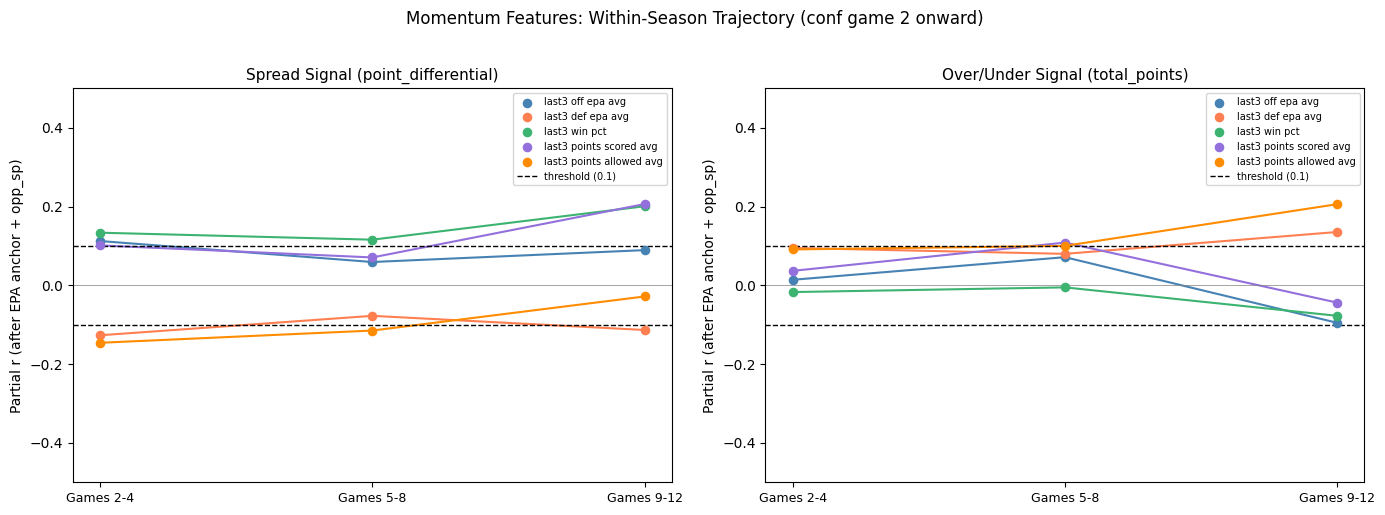

In [12]:
# Cell 12 — Q6 visualization: trajectory
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

band_names = list(band_labels.keys())
band_short = ["Games 2-4", "Games 5-8", "Games 9-12"]
x = np.arange(len(band_names))
colors = ["steelblue","coral","mediumseagreen","mediumpurple","darkorange"]

for ax, target, target_label in zip(
    axes,
    ["point_differential","total_points"],
    ["Spread Signal (point_differential)","Over/Under Signal (total_points)"]
):
    for feat, color in zip(list(trajectory_results.keys()), colors):
        rs = [trajectory_results[feat].get(bk,{}).get(
              "spread_r" if target=="point_differential" else "ou_r", np.nan)
              for bk in band_names]
        rs_arr = np.array(rs, dtype=float)
        for i in range(len(rs_arr)-1):
            if not np.isnan(rs_arr[i]) and not np.isnan(rs_arr[i+1]):
                ax.plot([x[i],x[i+1]], [rs_arr[i],rs_arr[i+1]], color=color, lw=1.5)
        valid_x = x[~np.isnan(rs_arr)]
        valid_y = rs_arr[~np.isnan(rs_arr)]
        if len(valid_x):
            ax.scatter(valid_x, valid_y, color=color, s=35, zorder=5,
                       label=feat.replace("_"," "))

    ax.axhline(THRESHOLD,  color="black", lw=1, ls="--", label=f"threshold ({THRESHOLD})")
    ax.axhline(-THRESHOLD, color="black", lw=1, ls="--")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(band_short, fontsize=9)
    ax.set_ylabel("Partial r (after EPA anchor + opp_sp)")
    ax.set_title(target_label, fontsize=11)
    ax.legend(fontsize=7)
    ax.set_ylim(-0.5, 0.5)

plt.suptitle("Momentum Features: Within-Season Trajectory (conf game 2 onward)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# Cell 13 — Q7: days_since_last_game — distribution and populations

print("=== Q7: DAYS SINCE LAST GAME — DISTRIBUTION AND POPULATIONS ===\n")

dslg = gdf_conf["days_since_last_game"].dropna()
print(f"Distribution (all conference games):")
print(f"  mean={dslg.mean():.1f}  median={dslg.median():.1f}  "
      f"SD={dslg.std():.1f}  min={dslg.min():.0f}  max={dslg.max():.0f}")

print(f"\nValue counts:")
for val, cnt in dslg.value_counts().sort_index().items():
    print(f"  {int(val):3d} days : {cnt:,}")

normal_rest = gdf_conf[gdf_conf["days_since_last_game"].between(5, 9)].copy()
bye_week    = gdf_conf[gdf_conf["days_since_last_game"] >= 12].copy()

print(f"\nPopulation breakdown:")
print(f"  Normal rest (5-9 days)  : {len(normal_rest):,}")
print(f"  Bye week (>=12 days)    : {len(bye_week):,}")
print(f"\nBye week by conference:")
for conf in sorted(gdf_conf["conference"].unique()):
    n = (bye_week["conference"] == conf).sum()
    print(f"  {conf:25s} {n:,}")

=== Q7: DAYS SINCE LAST GAME — DISTRIBUTION AND POPULATIONS ===

Distribution (all conference games):
  mean=8.1  median=7.0  SD=2.5  min=4  max=18

Value counts:
    4 days : 4
    5 days : 60
    6 days : 364
    7 days : 1,773
    8 days : 402
    9 days : 68
   10 days : 42
   11 days : 43
   12 days : 39
   13 days : 63
   14 days : 276
   15 days : 55
   16 days : 8
   17 days : 4
   18 days : 2

Population breakdown:
  Normal rest (5-9 days)  : 2,667
  Bye week (>=12 days)    : 447

Bye week by conference:
  ACC                       64
  American Athletic         52
  Big 12                    53
  Big Ten                   60
  Conference USA            36
  Mid-American              19
  Mountain West             42
  Pac-12                    24
  SEC                       58
  Sun Belt                  39


In [14]:
# Cell 14 — Q8: days_since_last_game — conference-stratified signal

print("=== Q8: DAYS SINCE LAST GAME — CONFERENCE-STRATIFIED SIGNAL ===\n")
print("Controls: EPA anchor pair + opp_sp_rating_at_game_time\n")

dslg_spread_full = conf_stratified_partial_r(
    gdf_conf, "days_since_last_game", "point_differential", CONTROLS,
    label="SPREAD — all conf games"
)
print()
dslg_ou_full = conf_stratified_partial_r(
    gdf_conf, "days_since_last_game", "total_points", CONTROLS,
    label="O/U — all conf games"
)

print(f"\n--- Bye week population (>=12d) — conference-stratified ---")
dslg_spread_bye = conf_stratified_partial_r(
    bye_week, "days_since_last_game", "point_differential", CONTROLS,
    label="SPREAD — bye week only"
)
print()
dslg_ou_bye = conf_stratified_partial_r(
    bye_week, "days_since_last_game", "total_points", CONTROLS,
    label="O/U — bye week only"
)

# Scoring comparison: bye vs normal by conference
print(f"\n--- Scoring comparison: bye week vs normal rest by conference ---")
print(f"  {'Conference':25s} {'bye_diff_mean':>15} {'normal_diff_mean':>18} {'delta':>8} {'p':>10}")
print(f"  {'-'*80}")
for conf in sorted(gdf_conf["conference"].unique()):
    bye_c    = bye_week[bye_week["conference"]==conf]["point_differential"].dropna()
    normal_c = normal_rest[normal_rest["conference"]==conf]["point_differential"].dropna()
    if len(bye_c) < 5 or len(normal_c) < 5:
        continue
    t, p = stats.ttest_ind(bye_c, normal_c)
    delta = bye_c.mean() - normal_c.mean()
    print(f"  {conf:25s} {bye_c.mean():>+15.2f} {normal_c.mean():>+18.2f} "
          f"{delta:>+8.2f} {p:>10.4f}{'  ✓' if p<0.05 else ''}")

=== Q8: DAYS SINCE LAST GAME — CONFERENCE-STRATIFIED SIGNAL ===

Controls: EPA anchor pair + opp_sp_rating_at_game_time


  days_since_last_game → point_differential | SPREAD — all conf games
  Population                    partial_r          p        n   signal
  -----------------------------------------------------------------
  Full population                  0.0257     0.2352    2,137        ✗
  P4                               0.0380     0.2158    1,064        ✗
  G5                               0.0090     0.7688    1,073        ✗
  ACC                              0.1394     0.0258      256        ✓
  American Athletic               -0.0111     0.8667      230        ✗
  Big 12                           0.0305     0.6131      278        ✗
  Big Ten                          0.0031     0.9584      286        ✗
  Conference USA                  -0.0434     0.6282      127        ✗
  Mid-American                     0.0851     0.2405      192        ✗
  Mountain West               

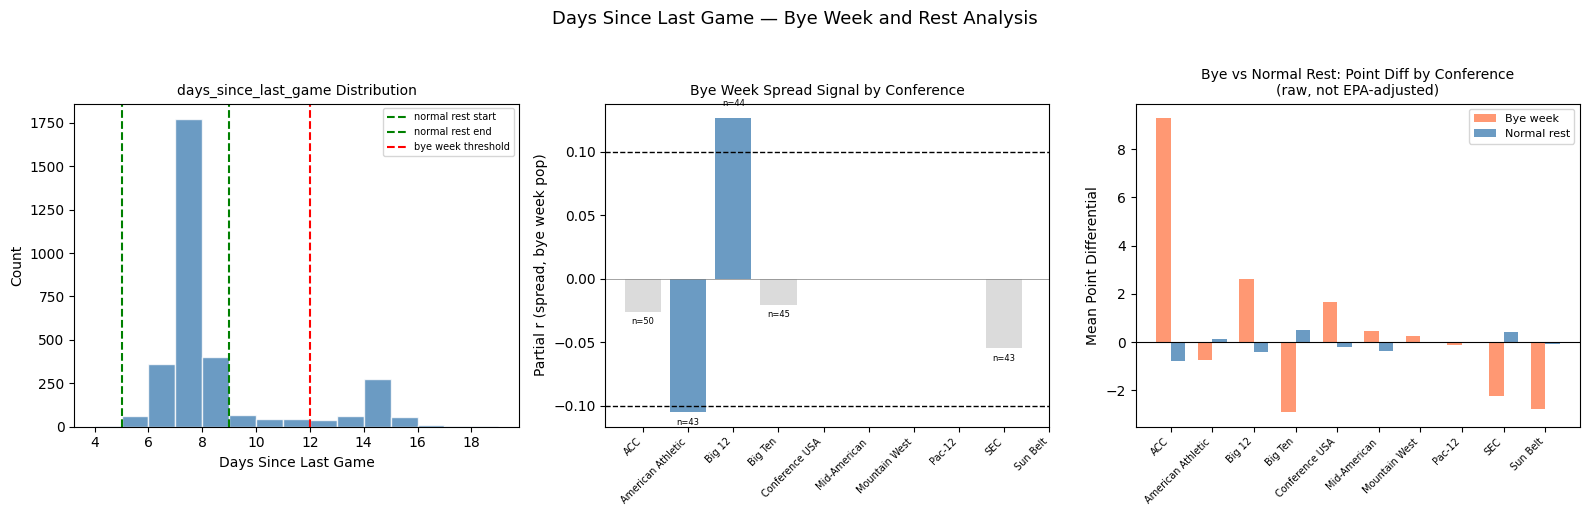

In [15]:
# Cell 15 — Q8 visualization: days_since_last_game
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Distribution
dslg_vals = gdf_conf["days_since_last_game"].dropna()
axes[0].hist(dslg_vals, bins=range(int(dslg_vals.min()), int(dslg_vals.max())+2),
             color="steelblue", alpha=0.8, edgecolor="white")
axes[0].axvline(5,  color="green", lw=1.5, ls="--", label="normal rest start")
axes[0].axvline(9,  color="green", lw=1.5, ls="--", label="normal rest end")
axes[0].axvline(12, color="red",   lw=1.5, ls="--", label="bye week threshold")
axes[0].set_xlabel("Days Since Last Game")
axes[0].set_ylabel("Count")
axes[0].set_title("days_since_last_game Distribution", fontsize=10)
axes[0].legend(fontsize=7)

# 2. Conference-stratified partial r — bye week spread signal
confs = sorted(bye_week["conference"].unique())
r_bye_vals = [dslg_spread_bye.get(c,{}).get("r",np.nan) for c in confs]
n_bye_vals = [dslg_spread_bye.get(c,{}).get("n",0) for c in confs]
x = np.arange(len(confs))
bars = axes[1].bar(x, r_bye_vals, color=[
    "steelblue" if (not np.isnan(r) and abs(r) >= THRESHOLD) else "lightgray"
    for r in r_bye_vals
], alpha=0.8)
axes[1].axhline(THRESHOLD,  color="black", lw=1, ls="--")
axes[1].axhline(-THRESHOLD, color="black", lw=1, ls="--")
axes[1].axhline(0, color="gray", lw=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(confs, rotation=45, ha="right", fontsize=7)
axes[1].set_ylabel("Partial r (spread, bye week pop)")
axes[1].set_title("Bye Week Spread Signal by Conference", fontsize=10)
for i, (r, n) in enumerate(zip(r_bye_vals, n_bye_vals)):
    if not np.isnan(r):
        axes[1].text(i, r + 0.01*np.sign(r), f"n={n}", ha="center", fontsize=6)

# 3. Bye vs normal mean point_differential by conference
confs_both = sorted(set(bye_week["conference"].unique()) &
                    set(normal_rest["conference"].unique()))
bye_means    = [bye_week[bye_week["conference"]==c]["point_differential"].mean()
                for c in confs_both]
normal_means = [normal_rest[normal_rest["conference"]==c]["point_differential"].mean()
                for c in confs_both]
x = np.arange(len(confs_both))
w = 0.35
axes[2].bar(x-w/2, bye_means,    w, label="Bye week",    color="coral",    alpha=0.8)
axes[2].bar(x+w/2, normal_means, w, label="Normal rest", color="steelblue", alpha=0.8)
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(confs_both, rotation=45, ha="right", fontsize=7)
axes[2].set_ylabel("Mean Point Differential")
axes[2].set_title("Bye vs Normal Rest: Point Diff by Conference\n(raw, not EPA-adjusted)",
                  fontsize=10)
axes[2].legend(fontsize=8)

plt.suptitle("Days Since Last Game — Bye Week and Rest Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# Cell 16 — Q9: Moneyline variance signal

print("=== Q9: MONEYLINE VARIANCE SIGNAL ===\n")
print("SD of point_differential by feature quartile — range > 3 pts = signal\n")

variance_results = {}
rolling_feats = [f for f in momentum_features if f != "days_since_last_game"]
for feat in rolling_feats:
    sub = conf_g2plus[[feat,"point_differential","total_points"]].dropna().copy()
    if len(sub) < 100:
        print(f"{feat}: insufficient data (n={len(sub)})")
        variance_results[feat] = {"variance_signal_spread": False, "variance_signal_ou": False}
        continue
    try:
        sub["quartile"] = pd.qcut(sub[feat], q=4, labels=["Q1","Q2","Q3","Q4"],
                                  duplicates="drop")
    except ValueError:
        print(f"{feat}: cannot bin — too many duplicate values")
        variance_results[feat] = {"variance_signal_spread": False, "variance_signal_ou": False}
        continue

    grp_diff  = sub.groupby("quartile")["point_differential"].agg(["mean","std","count"])
    grp_total = sub.groupby("quartile")["total_points"].agg(["mean","std","count"])
    sd_range_diff  = grp_diff["std"].max()  - grp_diff["std"].min()
    sd_range_total = grp_total["std"].max() - grp_total["std"].min()
    print(f"{feat}")
    print(f"  point_diff  SD range: {sd_range_diff:.2f} pts  "
          f"{'✓ variance signal' if sd_range_diff > 3 else '✗ no variance signal'}")
    print(f"  total_pts   SD range: {sd_range_total:.2f} pts  "
          f"{'✓ variance signal' if sd_range_total > 3 else '✗ no variance signal'}")
    variance_results[feat] = {
        "variance_signal_spread": sd_range_diff > 3,
        "variance_signal_ou": sd_range_total > 3,
    }

=== Q9: MONEYLINE VARIANCE SIGNAL ===

SD of point_differential by feature quartile — range > 3 pts = signal

last3_off_epa_avg
  point_diff  SD range: 0.83 pts  ✗ no variance signal
  total_pts   SD range: 0.71 pts  ✗ no variance signal
last3_def_epa_avg
  point_diff  SD range: 0.78 pts  ✗ no variance signal
  total_pts   SD range: 1.66 pts  ✗ no variance signal
last3_win_pct: cannot bin — too many duplicate values
last3_points_scored_avg
  point_diff  SD range: 1.60 pts  ✗ no variance signal
  total_pts   SD range: 0.23 pts  ✗ no variance signal
last3_points_allowed_avg
  point_diff  SD range: 0.78 pts  ✗ no variance signal
  total_pts   SD range: 1.09 pts  ✗ no variance signal


In [17]:
# Cell 17 — Full verdict

print("=" * 100)
print("MOMENTUM AND ROLLING FEATURES — FULL VERDICT")
print("=" * 100)

def assign_momentum_role(feat, sp_r, ou_r, traj, conf_spread, conf_ou):
    sp_sig = not np.isnan(sp_r) and abs(sp_r) >= THRESHOLD
    ou_sig = not np.isnan(ou_r) and abs(ou_r) >= THRESHOLD

    # Check trajectory from games 2-4
    traj_g24_sp = traj.get("conf_games_2_4",{}).get("spread_r", np.nan)
    traj_g24_ou = traj.get("conf_games_2_4",{}).get("ou_r", np.nan)
    traj_holds = ((not np.isnan(traj_g24_sp) and abs(traj_g24_sp) >= THRESHOLD) or
                  (not np.isnan(traj_g24_ou) and abs(traj_g24_ou) >= THRESHOLD))

    # Check conference concentration
    confs_with_signal = [c for c, v in conf_spread.items()
                         if c not in ["full","P4","G5"] and
                         not np.isnan(v.get("r",np.nan)) and
                         abs(v.get("r",np.nan)) >= THRESHOLD]
    confs_no_signal = [c for c, v in conf_spread.items()
                       if c not in ["full","P4","G5"] and
                       (np.isnan(v.get("r",np.nan)) or
                        abs(v.get("r",np.nan)) < THRESHOLD)]

    if not sp_sig and not ou_sig:
        if confs_with_signal:
            return (f"conference-specific — signal in {confs_with_signal}, "
                    f"redundant in {confs_no_signal}")
        return "redundant — no signal after EPA anchor + opp_sp control"

    if traj_holds:
        if confs_with_signal and len(confs_no_signal) > 2:
            return (f"conference-specific supporting — signal holds from conf game 2, "
                    f"concentrates in {confs_with_signal}")
        return "supporting — in-season only, signal holds from conf game 2, no prior seed"
    return "supporting — late-season only, signal not present in conf games 2-4"

verdict_rows = []

# Rolling EPA
for feat in ["last3_off_epa_avg","last3_def_epa_avg"]:
    sp_r = rolling_epa_spread[feat].get("full",{}).get("r", np.nan)
    ou_r = rolling_epa_ou[feat].get("full",{}).get("r", np.nan)
    traj = trajectory_results.get(feat, {})
    var  = variance_results.get(feat, {})
    traj_g24_sp = traj.get("conf_games_2_4",{}).get("spread_r", np.nan)
    traj_g24_ou = traj.get("conf_games_2_4",{}).get("ou_r", np.nan)
    role = assign_momentum_role(feat, sp_r, ou_r, traj,
                                rolling_epa_spread[feat], rolling_epa_ou[feat])
    verdict_rows.append({
        "feature": feat,
        "population": "Conference games 2+ (non-null)",
        "spread_partial_r": round(float(sp_r), 4) if not np.isnan(sp_r) else np.nan,
        "spread_signal": not np.isnan(sp_r) and abs(sp_r) >= THRESHOLD,
        "ou_partial_r": round(float(ou_r), 4) if not np.isnan(ou_r) else np.nan,
        "ou_signal": not np.isnan(ou_r) and abs(ou_r) >= THRESHOLD,
        "traj_games_2_4_spread_r": round(float(traj_g24_sp),4) if not np.isnan(traj_g24_sp) else np.nan,
        "traj_games_2_4_ou_r": round(float(traj_g24_ou),4) if not np.isnan(traj_g24_ou) else np.nan,
        "variance_signal_spread": var.get("variance_signal_spread", False),
        "variance_signal_ou": var.get("variance_signal_ou", False),
        "yoy_r": np.nan,
        "yoy_stable": False,
        "verdict": role,
        "notes": "Opponent adjustment handled by opp_sp_rating_at_game_time control."
    })

# Rolling points and win pct
for feat in ["last3_points_scored_avg","last3_points_allowed_avg","last3_win_pct"]:
    sp_r = rolling_pts_spread[feat].get("full",{}).get("r", np.nan)
    ou_r = rolling_pts_ou[feat].get("full",{}).get("r", np.nan)
    traj = trajectory_results.get(feat, {})
    var  = variance_results.get(feat, {})
    traj_g24_sp = traj.get("conf_games_2_4",{}).get("spread_r", np.nan)
    traj_g24_ou = traj.get("conf_games_2_4",{}).get("ou_r", np.nan)
    role = assign_momentum_role(feat, sp_r, ou_r, traj,
                                rolling_pts_spread[feat], rolling_pts_ou[feat])
    verdict_rows.append({
        "feature": feat,
        "population": "Conference games 2+ (non-null)",
        "spread_partial_r": round(float(sp_r), 4) if not np.isnan(sp_r) else np.nan,
        "spread_signal": not np.isnan(sp_r) and abs(sp_r) >= THRESHOLD,
        "ou_partial_r": round(float(ou_r), 4) if not np.isnan(ou_r) else np.nan,
        "ou_signal": not np.isnan(ou_r) and abs(ou_r) >= THRESHOLD,
        "traj_games_2_4_spread_r": round(float(traj_g24_sp),4) if not np.isnan(traj_g24_sp) else np.nan,
        "traj_games_2_4_ou_r": round(float(traj_g24_ou),4) if not np.isnan(traj_g24_ou) else np.nan,
        "variance_signal_spread": var.get("variance_signal_spread", False),
        "variance_signal_ou": var.get("variance_signal_ou", False),
        "yoy_r": np.nan,
        "yoy_stable": False,
        "verdict": role,
        "notes": ""
    })

# days_since_last_game
sp_r_full = dslg_spread_full.get("full",{}).get("r", np.nan)
ou_r_full = dslg_ou_full.get("full",{}).get("r", np.nan)
sp_r_bye  = dslg_spread_bye.get("full",{}).get("r", np.nan)
ou_r_bye  = dslg_ou_bye.get("full",{}).get("r", np.nan)
n_bye     = dslg_spread_bye.get("full",{}).get("n", 0)

# Best population
use_bye = (not np.isnan(sp_r_bye) and
           (np.isnan(sp_r_full) or abs(sp_r_bye) >= abs(sp_r_full)))
best_sp  = sp_r_bye if use_bye else sp_r_full
best_ou  = ou_r_bye if use_bye else ou_r_full
best_pop = "Bye week (>=12d)" if use_bye else "All conf games"

confs_with_bye_signal = [c for c, v in dslg_spread_bye.items()
                         if c not in ["full","P4","G5"] and
                         not np.isnan(v.get("r",np.nan)) and
                         abs(v.get("r",np.nan)) >= THRESHOLD]

sp_sig = not np.isnan(best_sp) and abs(best_sp) >= THRESHOLD
ou_sig = not np.isnan(best_ou) and abs(best_ou) >= THRESHOLD

if not sp_sig and not ou_sig:
    if confs_with_bye_signal:
        dslg_verdict = (f"conference-specific — bye week signal in "
                        f"{confs_with_bye_signal}")
    else:
        dslg_verdict = "redundant — no signal after EPA anchor + opp_sp control"
else:
    dslg_verdict = "supporting — in-season only, no prior seed"

verdict_rows.append({
    "feature": "days_since_last_game",
    "population": best_pop,
    "spread_partial_r": round(float(best_sp), 4) if not np.isnan(best_sp) else np.nan,
    "spread_signal": sp_sig,
    "ou_partial_r": round(float(best_ou), 4) if not np.isnan(best_ou) else np.nan,
    "ou_signal": ou_sig,
    "traj_games_2_4_spread_r": np.nan,
    "traj_games_2_4_ou_r": np.nan,
    "variance_signal_spread": False,
    "variance_signal_ou": False,
    "yoy_r": np.nan,
    "yoy_stable": False,
    "verdict": dslg_verdict,
    "notes": (f"All games: spread r={sp_r_full:.4f}. "
              f"Bye week (n={n_bye}): spread r={sp_r_bye:.4f}. "
              f"Conferences with bye signal: {confs_with_bye_signal}.")
})

# Print
print(f"\n{'Feature':30s} {'Population':28s} {'spread_r':>10} {'ou_r':>10} "
      f"{'traj_2_4_sp':>12}  verdict")
print("-" * 120)
for row in verdict_rows:
    sp_str = f"{row['spread_partial_r']:.4f}" if isinstance(row['spread_partial_r'], float) and not np.isnan(row['spread_partial_r']) else "  nan "
    ou_str = f"{row['ou_partial_r']:.4f}"     if isinstance(row['ou_partial_r'], float) and not np.isnan(row['ou_partial_r']) else "  nan "
    t_str  = f"{row['traj_games_2_4_spread_r']:.4f}" if isinstance(row['traj_games_2_4_spread_r'], float) and not np.isnan(row['traj_games_2_4_spread_r']) else "  nan "
    print(f"  {row['feature']:28s} {row['population']:28s} {sp_str:>10} "
          f"{ou_str:>10} {t_str:>12}  {row['verdict']}")

print("\n" + "=" * 100)

MOMENTUM AND ROLLING FEATURES — FULL VERDICT

Feature                        Population                     spread_r       ou_r  traj_2_4_sp  verdict
------------------------------------------------------------------------------------------------------------------------
  last3_off_epa_avg            Conference games 2+ (non-null)     0.0818     0.0368       0.1124  conference-specific — signal in ['ACC', 'Conference USA', 'Mid-American', 'Mountain West', 'SEC'], redundant in ['American Athletic', 'Big 12', 'Big Ten', 'Pac-12', 'Sun Belt']
  last3_def_epa_avg            Conference games 2+ (non-null)    -0.0999     0.0869      -0.1268  conference-specific — signal in ['American Athletic', 'Big Ten', 'Conference USA', 'Mid-American', 'Pac-12'], redundant in ['ACC', 'Big 12', 'Mountain West', 'SEC', 'Sun Belt']
  last3_points_scored_avg      Conference games 2+ (non-null)     0.0918     0.0689       0.1012  conference-specific — signal in ['ACC', 'Big 12', 'Big Ten', 'Conference USA', 'M

In [18]:
# Cell 18 — Write verdict CSV
verdict_df = pd.DataFrame(verdict_rows)
path = os.path.expanduser("~/cfb-analytics/artifacts/momentum_verdict.csv")
verdict_df.to_csv(path, index=False)
print(f"Written to {path}")
print()
print(verdict_df[["feature","population","spread_partial_r","ou_partial_r",
                  "traj_games_2_4_spread_r","verdict"]].to_string(index=False))

cur.close()
conn.close()
print("\nDB connection closed. Day 12 Momentum and Rolling Features complete.")

Written to /Users/kevinjohnson/cfb-analytics/artifacts/momentum_verdict.csv

                 feature                     population  spread_partial_r  ou_partial_r  traj_games_2_4_spread_r                                                                                                                                                                          verdict
       last3_off_epa_avg Conference games 2+ (non-null)            0.0818        0.0368                   0.1124 conference-specific — signal in ['ACC', 'Conference USA', 'Mid-American', 'Mountain West', 'SEC'], redundant in ['American Athletic', 'Big 12', 'Big Ten', 'Pac-12', 'Sun Belt']
       last3_def_epa_avg Conference games 2+ (non-null)           -0.0999        0.0869                  -0.1268 conference-specific — signal in ['American Athletic', 'Big Ten', 'Conference USA', 'Mid-American', 'Pac-12'], redundant in ['ACC', 'Big 12', 'Mountain West', 'SEC', 'Sun Belt']
 last3_points_scored_avg Conference games 2+ (non-nul